# Notebook Purpose

Train and evaluate baseline models, then persist selected model artifacts.


## Workflow

Setup, run, evaluate, and save outputs.


In [1]:
# Cell 1: Imports
import sys
sys.path.append('..')

from src.models.baselines import (
    PopularityBaseline, 
    UserHeuristicBaseline, 
    LGBMBaseline,
    evaluate_model,
    print_metrics
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Imports successful")


✅ Imports successful


In [2]:
# Cell 2: Load data
print("Loading data...")

train_df = pd.read_parquet('../data/processed/train_dataset.parquet')
val_df = pd.read_parquet('../data/processed/val_dataset.parquet')

print(f"✅ Train: {train_df.shape}")
print(f"✅ Val: {val_df.shape}")

# Get labels
y_train = train_df['reordered']
y_val = val_df['reordered']

print(f"\nTrain positive rate: {y_train.mean():.2%}")
print(f"Val positive rate: {y_val.mean():.2%}")


Loading data...
✅ Train: (6777721, 45)
✅ Val: (1696940, 45)

Train positive rate: 9.79%
Val positive rate: 9.73%


In [5]:
# Cell 3: Baseline 1 - Popularity
print("="*60)
print("BASELINE 1: POPULARITY")
print("="*60)

popularity_model = PopularityBaseline()
popularity_model.fit(train_df)

# Predict on val
y_pred_pop = popularity_model.predict(val_df)

# Evaluate
metrics_pop = evaluate_model(y_val, y_pred_pop)
print_metrics(metrics_pop, "Popularity Baseline")


BASELINE 1: POPULARITY
Training Popularity Baseline...
✅ Selected top 1000 products

Popularity Baseline Performance:
  PRECISION   : 0.1318
  RECALL      : 0.5880
  F1          : 0.2153


In [6]:
# Cell 4: Baseline 2 - User Heuristic
print("\n" + "="*60)
print("BASELINE 2: USER HEURISTIC")
print("="*60)

heuristic_model = UserHeuristicBaseline(times_threshold=3, recency_threshold=5)
heuristic_model.fit(train_df)

# Predict on val
y_pred_heur = heuristic_model.predict(val_df)

# Evaluate
metrics_heur = evaluate_model(y_val, y_pred_heur)
print_metrics(metrics_heur, "Heuristic Baseline")



BASELINE 2: USER HEURISTIC
Using heuristic thresholds:
  - Times bought >= 3
  - Orders since last <= 5

Heuristic Baseline Performance:
  PRECISION   : 0.3048
  RECALL      : 0.4934
  F1          : 0.3768


In [3]:
# Cell 5: Baseline 3 - LightGBM
print("\n" + "="*60)
print("BASELINE 3: LIGHTGBM")
print("="*60)

lgbm_model = LGBMBaseline()

# Train (might take 3-5 minutes)
lgbm_model.fit(
    train_df, 
    val_df=val_df,
    num_boost_round=500,
    early_stopping_rounds=50
)

# Predict on val
y_prob_lgbm = lgbm_model.predict(val_df)

# Evaluate with different thresholds
print("\nEvaluating with threshold = 0.5:")
metrics_lgbm_05 = evaluate_model(y_val, None, y_prob_lgbm, threshold=0.5)
print_metrics(metrics_lgbm_05, "LightGBM (threshold=0.5)")

print("\nEvaluating with threshold = 0.21 (optimized for F1):")
metrics_lgbm_21 = evaluate_model(y_val, None, y_prob_lgbm, threshold=0.21)
print_metrics(metrics_lgbm_21, "LightGBM (threshold=0.21)")



BASELINE 3: LIGHTGBM
Training LightGBM model...
  Using 42 features
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.829553	valid's auc: 0.829419
[100]	train's auc: 0.831377	valid's auc: 0.831
[150]	train's auc: 0.832303	valid's auc: 0.831689
[200]	train's auc: 0.832943	valid's auc: 0.832049
[250]	train's auc: 0.833453	valid's auc: 0.832272
[300]	train's auc: 0.833929	valid's auc: 0.832419
[350]	train's auc: 0.834329	valid's auc: 0.832502
[400]	train's auc: 0.83469	valid's auc: 0.832595
[450]	train's auc: 0.835037	valid's auc: 0.832664
[500]	train's auc: 0.83539	valid's auc: 0.832732
Did not meet early stopping. Best iteration is:
[500]	train's auc: 0.83539	valid's auc: 0.832732
✅ Training completed. Best iteration: 500

Evaluating with threshold = 0.5:

LightGBM (threshold=0.5) Performance:
  PRECISION   : 0.6320
  RECALL      : 0.1756
  F1          : 0.2748
  AUC         : 0.8327

Evaluating with threshold = 0.21 (optimized for F1):

LightGBM (thresho


MODEL COMPARISON
                 precision    recall        f1       auc
Popularity        0.131812  0.587996  0.215350       NaN
Heuristic         0.304787  0.493394  0.376807       NaN
LightGBM (0.5)    0.631994  0.175555  0.274782  0.832732
LightGBM (0.21)   0.383086  0.511468  0.438065  0.832732


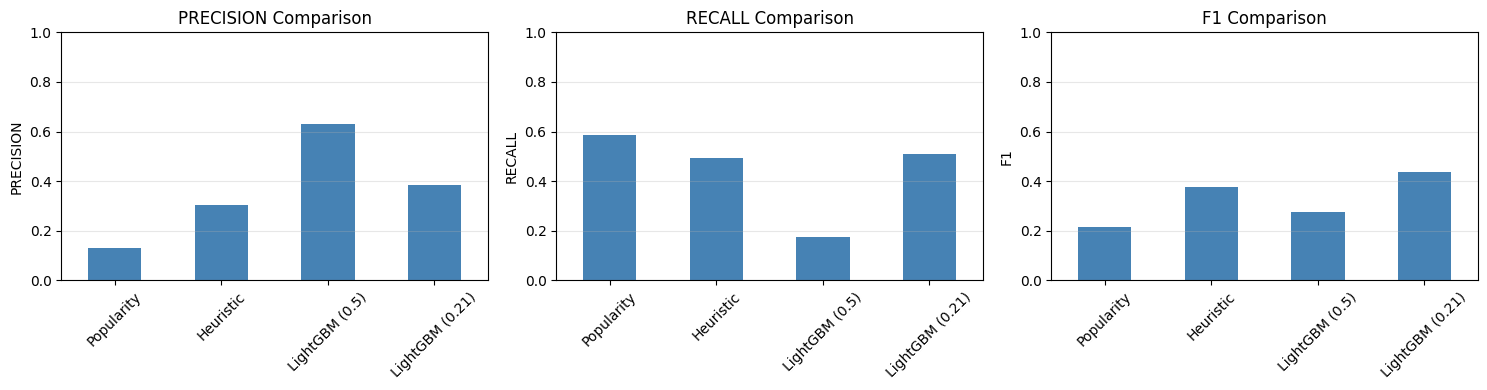

In [7]:
# Cell 6: Compare all models
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison = pd.DataFrame({
    'Popularity': metrics_pop,
    'Heuristic': metrics_heur,
    'LightGBM (0.5)': metrics_lgbm_05,
    'LightGBM (0.21)': metrics_lgbm_21,
}).T

print(comparison)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_to_plot = ['precision', 'recall', 'f1']
for i, metric in enumerate(metrics_to_plot):
    comparison[metric].plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{metric.upper()} Comparison')
    axes[i].set_ylabel(metric.upper())
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/figures/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



FEATURE IMPORTANCE

Top 15 Most Important Features:
                      feature    importance
12               up_rfm_score  4.750554e+06
9   up_order_rate_since_first  1.096938e+06
13        up_order_streak_max  6.253507e+05
25      product_reorder_ratio  3.490279e+05
6        up_orders_since_last  3.115231e+05
0             up_times_bought  2.566249e+05
40    user_dept_reorder_ratio  1.927388e+05
5            up_reorder_ratio  1.712601e+05
17         user_reorder_ratio  1.064535e+05
23     user_product_diversity  9.072814e+04
14    up_order_streak_current  6.085400e+04
1        up_last_order_number  4.741885e+04
8       up_purchase_frequency  3.670270e+04
24             product_orders  2.936423e+04
28               product_rank  2.853049e+04


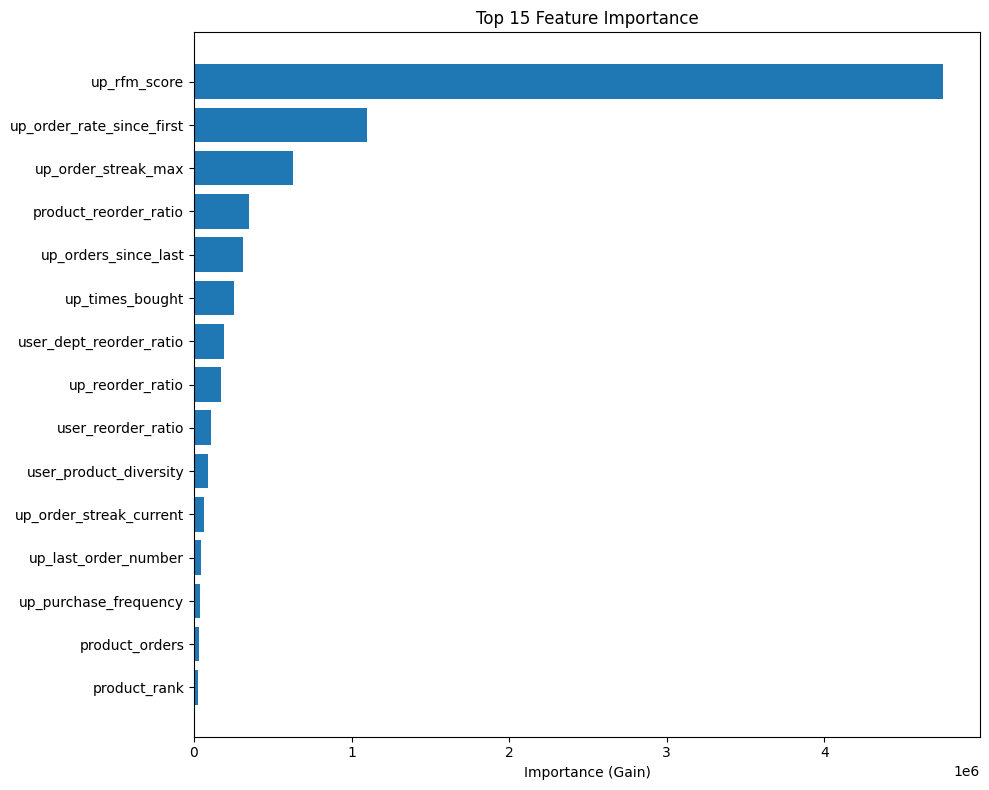

In [8]:
# Cell 7: Feature Importance
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = lgbm_model.get_feature_importance()
print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gain)')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../notebooks/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



THRESHOLD ANALYSIS

✅ Best threshold for F1: 0.20


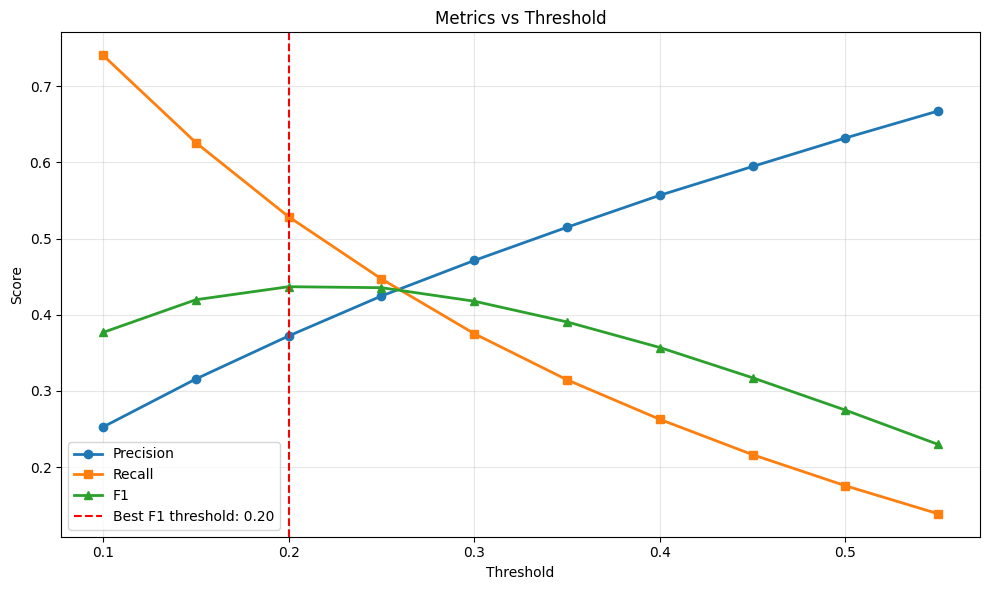

In [9]:
# Cell 8: Threshold Analysis
print("\n" + "="*60)
print("THRESHOLD ANALYSIS")
print("="*60)

# Try different thresholds
thresholds = np.arange(0.1, 0.6, 0.05)
results = []

for threshold in thresholds:
    metrics = evaluate_model(y_val, None, y_prob_lgbm, threshold=threshold)
    results.append({
        'threshold': threshold,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1']
    })

threshold_df = pd.DataFrame(results)

# Find best threshold for F1
best_threshold = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
print(f"\n✅ Best threshold for F1: {best_threshold:.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['threshold'], threshold_df['precision'], 
         marker='o', label='Precision', linewidth=2)
plt.plot(threshold_df['threshold'], threshold_df['recall'], 
         marker='s', label='Recall', linewidth=2)
plt.plot(threshold_df['threshold'], threshold_df['f1'], 
         marker='^', label='F1', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', 
            label=f'Best F1 threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Cell 9: Summary
print("\n" + "="*60)
print("BASELINE MODELS SUMMARY")
print("="*60)

print("\n✅ Completed training 3 baseline models:")
print("  1. Popularity Baseline - Simple but weak")
print("  2. Heuristic Baseline - Better, rule-based")
print("  3. LightGBM - Best performer")

print(f"\n🎯 Best Model: LightGBM")
print(f"   - AUC: {metrics_lgbm_05['auc']:.4f}")
print(f"   - Best F1: {threshold_df['f1'].max():.4f} (at threshold {best_threshold:.2f})")
print(f"   - Precision: {threshold_df.loc[threshold_df['f1'].idxmax(), 'precision']:.4f}")
print(f"   - Recall: {threshold_df.loc[threshold_df['f1'].idxmax(), 'recall']:.4f}")

print("\n📊 Top 5 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.0f}")

print("\n💡 Key Insights:")
print("  - User-product interaction features are most important")
print("  - High AUC shows model can distinguish reorders well")
print("  - Threshold tuning significantly improves F1 score")



BASELINE MODELS SUMMARY

✅ Completed training 3 baseline models:
  1. Popularity Baseline - Simple but weak
  2. Heuristic Baseline - Better, rule-based
  3. LightGBM - Best performer

🎯 Best Model: LightGBM
   - AUC: 0.8327
   - Best F1: 0.4368 (at threshold 0.20)
   - Precision: 0.3721
   - Recall: 0.5286

📊 Top 5 Most Important Features:
   13. up_rfm_score: 4750554
   10. up_order_rate_since_first: 1096938
   14. up_order_streak_max: 625351
   26. product_reorder_ratio: 349028
   7. up_orders_since_last: 311523

💡 Key Insights:
  - User-product interaction features are most important
  - High AUC shows model can distinguish reorders well
  - Threshold tuning significantly improves F1 score


In [11]:
# Cell 10: Save trained model

import joblib
import os

# Create output directory
os.makedirs('../models/saved', exist_ok=True)

# Save LightGBM model
joblib.dump(lgbm_model, '../models/saved/lgbm_baseline.pkl')

print("✅ Model saved to ../models/saved/lgbm_baseline.pkl")


✅ Model saved to ../models/saved/lgbm_baseline.pkl


In [12]:
# Cell: F1 OPTIMIZATION
from sklearn.metrics import f1_score
import importlib
import src.models.f1_optimizer
importlib.reload(src.models.f1_optimizer)
from src.models.f1_optimizer import F1Optimizer

print("="*60)
print("F1 OPTIMIZATION")
print("="*60)

optimizer = F1Optimizer()

# Current approach
y_pred_fixed = (y_prob_lgbm >= 0.21).astype(int)
f1_fixed = f1_score(y_val, y_pred_fixed)
print(f"\nFixed threshold (0.21): F1 = {f1_fixed:.4f}")

# Global threshold search (fast - 100 thresholds only)
print("\nRunning global threshold search...")
y_pred_global, best_thresh, f1_global = optimizer.maximize_expectation(
    y_val.values,
    y_prob_lgbm
)
print(f"Global optimized: F1 = {f1_global:.4f} (threshold={best_thresh:.3f})")

# Per-user optimization (should take ~1-2 min for 26K users)
print("\nRunning per-user optimization...")
y_pred_peruser, _, f1_peruser = optimizer.maximize_expectation(
    y_val.values,
    y_prob_lgbm,
    user_ids=val_df['user_id'].values
)
print(f"Per-user optimized: F1 = {f1_peruser:.4f}")

print(f"\n📊 Summary:")
print(f"  Fixed threshold:    {f1_fixed:.4f}")
print(f"  Global optimized:   {f1_global:.4f}  (+{f1_global-f1_fixed:.4f})")
print(f"  Per-user optimized: {f1_peruser:.4f}  (+{f1_peruser-f1_fixed:.4f})")


F1 OPTIMIZATION

Fixed threshold (0.21): F1 = 0.4381

Running global threshold search...
Global optimized: F1 = 0.4385 (threshold=0.218)

Running per-user optimization...
  Optimizing for 26,242 users...
  Progress: 0%
  Progress: 10%
  Progress: 20%
  Progress: 30%
  Progress: 40%
  Progress: 50%
  Progress: 60%
  Progress: 70%
  Progress: 80%
  Progress: 90%
  Progress: 100%
Per-user optimized: F1 = 0.5069

📊 Summary:
  Fixed threshold:    0.4381
  Global optimized:   0.4385  (+0.0004)
  Per-user optimized: 0.5069  (+0.0688)


In [13]:
# Save model and F1 optimizer results
import joblib
import os

os.makedirs('../models/saved', exist_ok=True)

# Save LightGBM model
joblib.dump(lgbm_model, '../models/saved/lgbm_baseline.pkl')

# Save optimized predictions for reference
import numpy as np
np.save('../models/saved/val_predictions.npy', y_prob_lgbm)
np.save('../models/saved/val_peruser_predictions.npy', y_pred_peruser)

print("✅ Model and predictions saved!")
print(f"\n📊 Final Model Performance:")
print(f"   AUC:                  {metrics_lgbm_05['auc']:.4f}")
print(f"   F1 (fixed thresh):    0.4381")
print(f"   F1 (per-user optim):  0.5069  ← Best!")


✅ Model and predictions saved!

📊 Final Model Performance:
   AUC:                  0.8327
   F1 (fixed thresh):    0.4381
   F1 (per-user optim):  0.5069  ← Best!
